| Name                        | Questions        | Contribution                                                                 |
|-----------------------------|------------------|------------------------------------------------------------------------------|
| Jisna D Kunju               |                  |                                                                              |
| Jissy Jayaprakash           |                  |                                                                              |
| Anjitha Mohan               |      |    |
| Aman Nain                   |                  |                                                                              |
| Prakash Phakami Pun         |                  |                                                                              |
| Bibek Ranjit                |                  |                                                                              |
| Leandro Sartini de Campos   |   |                                 |
| Jorge Rodrigo Velazquez     |  |                                         |


For the group assignment, build the following generative models to generate images using the Yelp dataset.

1. a DCGAN

2. a WGAN

3. a VAE (variational autoencoder)

4. a cGAN (to generate the images as per the label [food, drink, inside, outside])

Evaluate the models using Inception Score and Frechet Inception Distance using a pretrained model

Submit 5 generated images (atleast one for each label in the cGAN) using each model

At the top of your ipynb files, share the 5 generated images using each model and the IS and FID metrics for each model. Clear and specific responses are expected.

Submit your ipynb file run end-to-end sequentially, and convert it to pdf.



Prompt Used:



# Imports

In [1]:
import json
import os
import warnings
warnings.filterwarnings("ignore")
#!pip install opencv-python
#!pip install matplotlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelBinarizer

import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Optionally suppress other verbose logs
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Model

2025-03-24 11:19:20.908650: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-24 11:19:21.420754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742829561.523906     543 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742829561.552082     543 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742829561.825075     543 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Data Exploration

In [2]:
data = []
json_path = '../Dataset/photos.json'

with open(json_path, 'r') as file:
    for line in file:
        data.append(json.loads(line.strip()))

In [3]:
len(data)

200100

In [4]:
data[0]

{'photo_id': 'zsvj7vloL4L5jhYyPIuVwg',
 'business_id': 'Nk-SJhPlDBkAZvfsADtccA',
 'caption': 'Nice rock artwork everywhere and craploads of taps.',
 'label': 'inside'}

In [5]:
#Lets extract the photo ID from the json file
photo_ids_json = [entry['photo_id'] for entry in data]

In [6]:
# Check the photos folder
photos_folder = '../Dataset/photos'
photo_files = os.listdir(photos_folder)
photo_ids_folder = [os.path.splitext(file)[0] for file in photo_files]

In [7]:
missing_photos = set(photo_ids_json) - set(photo_ids_folder)
extra_photos = set(photo_ids_folder) - set(photo_ids_json)


In [8]:
missing_photos

set()

In [9]:
extra_photos

set()

We can see there are no extra or missing photos between the json file and the photos folder

BGR (Blue-Green-Red): This is the default color format used by OpenCV when it reads an image. The pixel values are stored in the order of blue, green, and red channels.
RGB (Red-Green-Blue): This is the standard color format used for displaying images in most visualization tools, including matplotlib.

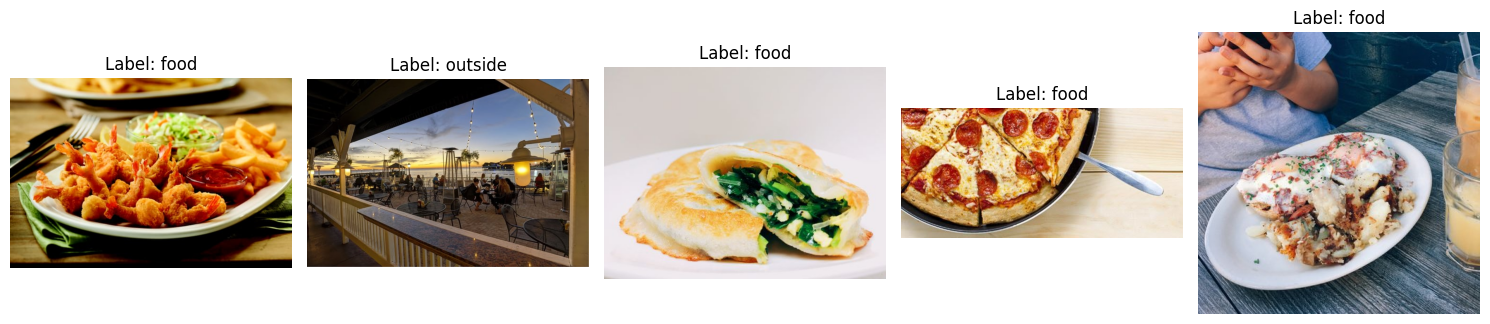

In [10]:
def show_sample_images(data, photos_folder, num_samples=5):
    # Randomly select samples from the dataset
    samples = random.sample(data, num_samples)

    # Create a plot
    plt.figure(figsize=(15, 10))

    for i, entry in enumerate(samples):
        photo_id = entry['photo_id']
        label = entry['label']
        img_path = os.path.join(photos_folder, photo_id + '.jpg')

        # Load the image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for visualization

        # Display the image with its label
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {label}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display images
show_sample_images(data, photos_folder, num_samples=5)


In this sample we can see 5 images and the label associated, so we can give us an idea of the type of images and clases present in the dataset

In [11]:
classes=[]
for i,entry in enumerate(data):
    label = entry['label']
    classes.append(label)

set(classes)

{'drink', 'food', 'inside', 'menu', 'outside'}

We can see the dataset contains 5 different classes: 'drink', 'food', 'inside', 'menu', 'outside'

Check for data imbalance

In [12]:
df = pd.DataFrame(data)
label_counts = df['label'].value_counts()
label_counts


label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64

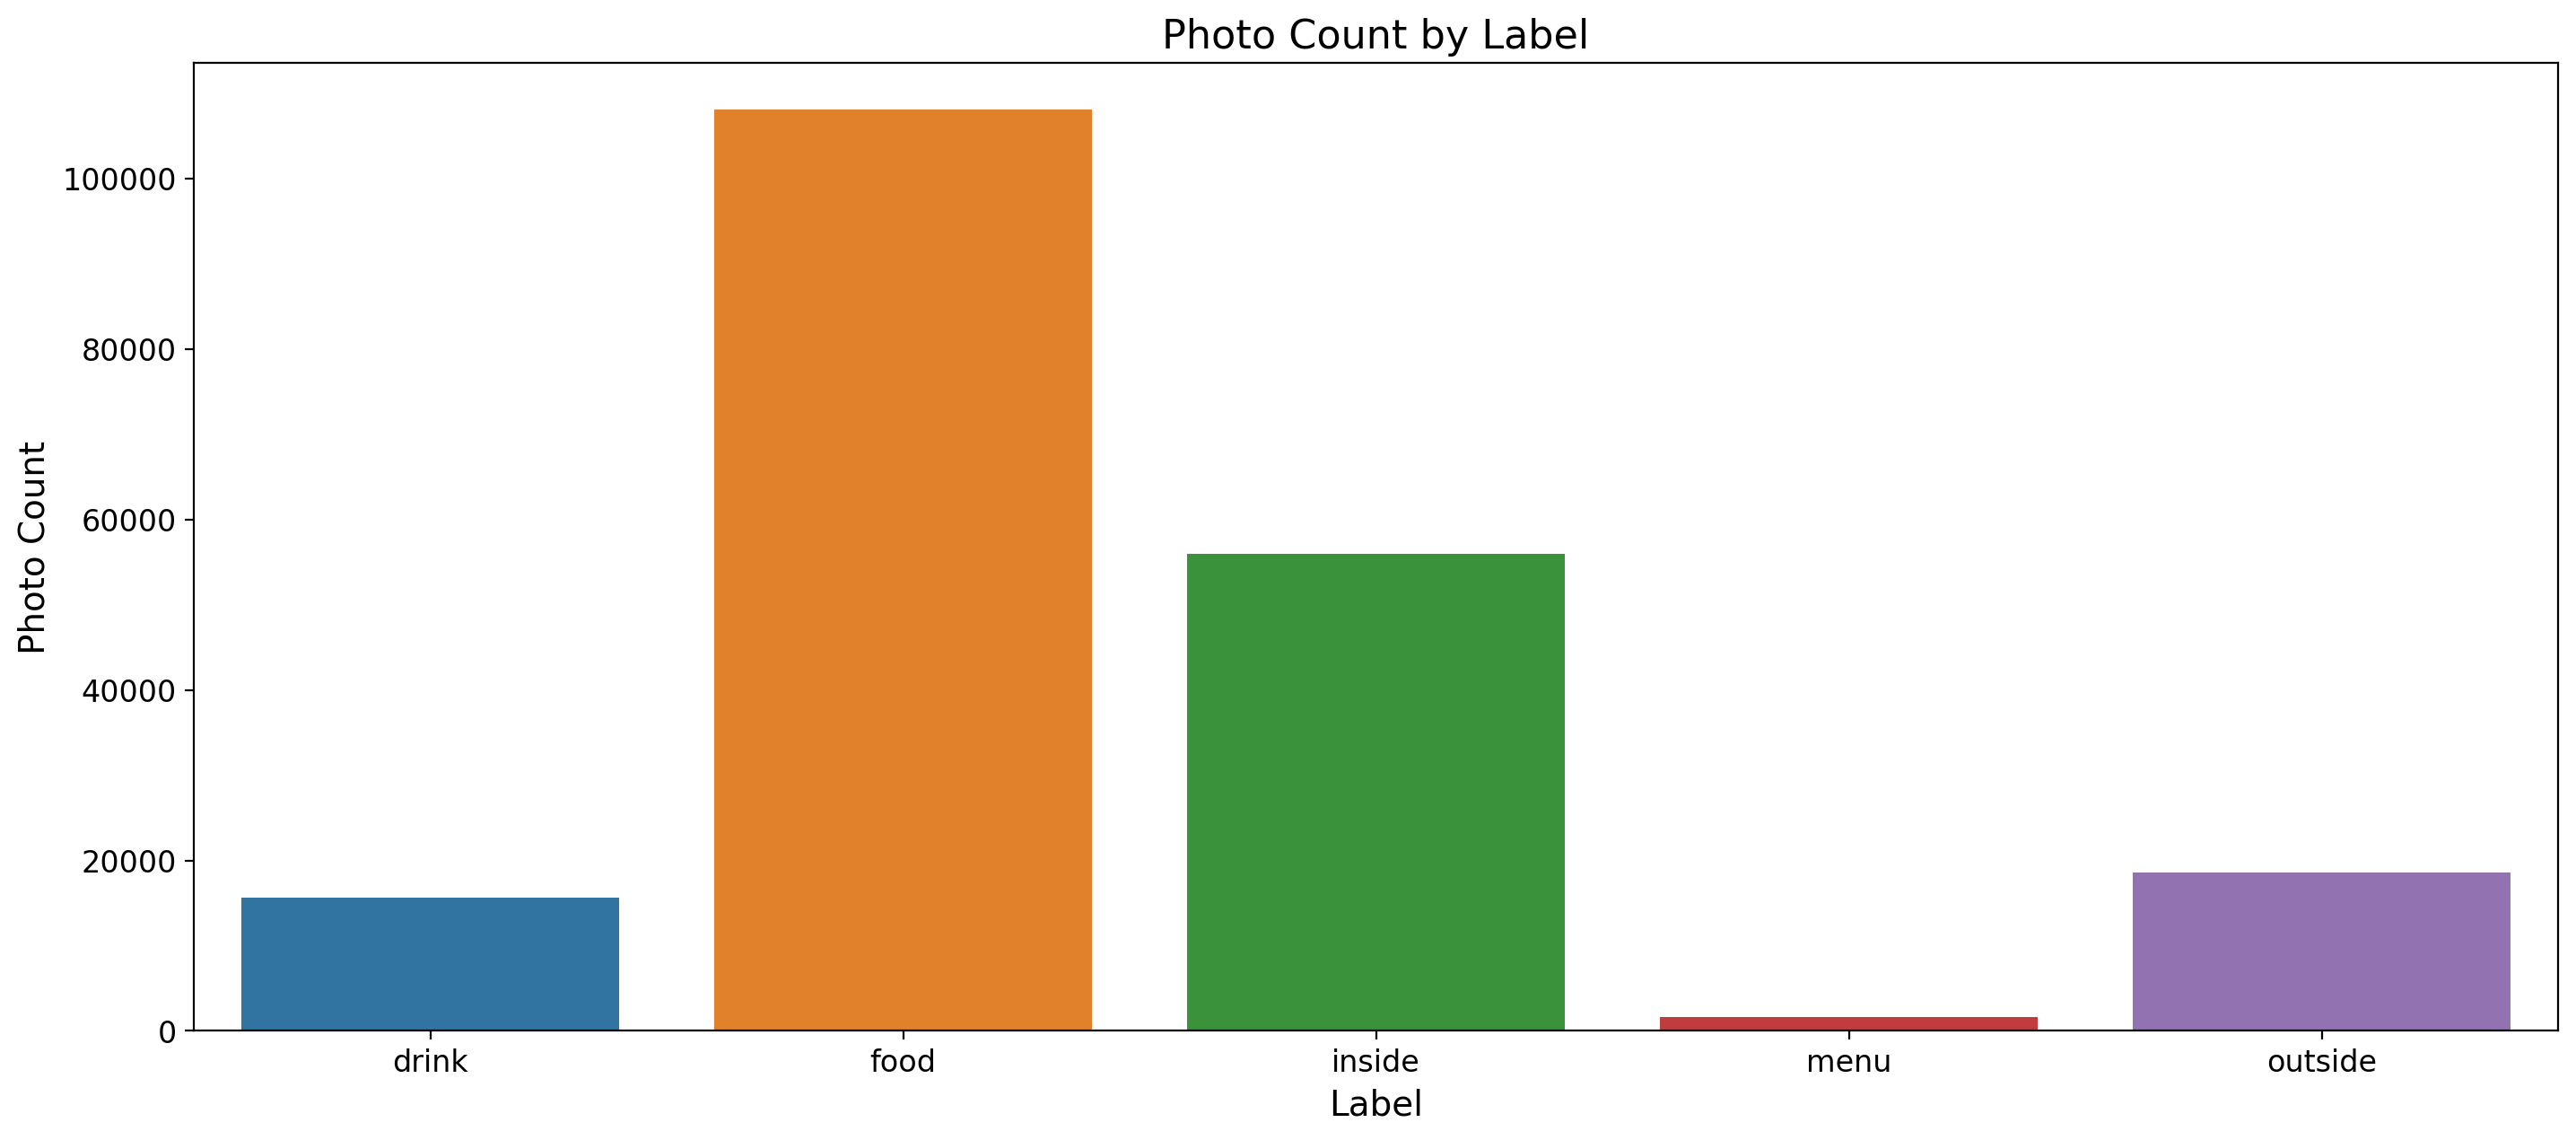

In [13]:
plt.figure(figsize=[17, 7],dpi=200)
sns.barplot(data=df.groupby('label')['photo_id'].count().to_frame().reset_index(),x='label', hue='label', y='photo_id')
plt.title("Photo Count by Label", fontsize=16)
plt.xlabel("Label", fontsize=14)
plt.ylabel("Photo Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

We can appreciate the menu class is being underrepresented, so before training we will perform data augmentation. 

# Functions

In [5]:
import tensorflow as tf

# List available GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Set memory growth for each GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set for GPUs.")
    except RuntimeError as e:
        print(f"Error setting memory growth: {e}")
else:
    print("No GPU found.")


Memory growth set for GPUs.


In [58]:
photos_df = pd.read_json(json_path, lines=True)

In [61]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [2]:
# Ensure TensorFlow uses GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Prevent full memory allocation
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("✅ GPU is now being used for TensorFlow!")
    except RuntimeError as e:
        print(e)

✅ GPU is now being used for TensorFlow!


### Filter Valid Images using GPU and TF

In [29]:
# def filter_valid_images(photo_ids, img_dir):
# #    """Check for missing/corrupt images and return a cleaned DataFrame."""
#     valid_photo_ids = []
#     invalid_photo_ids = []
# #
#     for photo_id in photo_ids:
#         img_path = os.path.join(img_dir, f"{photo_id}.jpg")
#         if os.path.exists(img_path):
#             try:
#                 img = tf.io.read_file(img_path)
#                 img = tf.image.decode_jpeg(img, channels=3)  # Try decoding to detect corruption
#                 valid_photo_ids.append(photo_id)
#             except tf.errors.InvalidArgumentError:
#                 invalid_photo_ids.append(photo_id)

#     print(f"✅ {len(valid_photo_ids)} valid images, ❌ {len(invalid_photo_ids)} corrupt images removed.")
#     return valid_photo_ids

# # Filter the dataset and update the DataFrame
# valid_photo_ids = filter_valid_images(photos_df["photo_id"], "Dataset/photos")
# cleaned_photos_df = photos_df[photos_df["photo_id"].isin(valid_photo_ids)].reset_index(drop=True)

# ## Save cleaned DataFrame
# cleaned_photos_df.to_csv("cleaned_photos.csv", index=False)

cleaned_photos_df = pd.read_csv("../Dataset/cleaned_photos.csv")

### Load Image in batches with TF

In [30]:
def load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(224, 224), batch_size=256):
    """Load images and labels using tf.data, handling corrupt images."""
    
    image_paths = [os.path.join(img_dir, f"{photo_id}.jpg") for photo_id in photo_ids]
    
    def load_image_label(image_path, label):
        """Load and preprocess a single image while handling corrupt images."""
        img = tf.io.read_file(image_path)
        
        try:
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, IMAGE_SIZE)
            
            # Ensure dtype is uint8 before converting
            #img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
            img = (tf.cast(img, tf.float32) / 127.5) - 1.0  # Normalize to [-1,1]

            
            return img, label  # Return image + label
        except tf.errors.InvalidArgumentError:
            print(f"Skipping corrupt image: {image_path}")
            return tf.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), label  # Keep batch shape consistent

    # Create a TensorFlow Dataset with GPU acceleration
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [31]:
from sklearn.preprocessing import LabelEncoder
# Convert labels to integers
label_encoder = LabelEncoder()
cleaned_photos_df["label"] = label_encoder.fit_transform(cleaned_photos_df["label"])

# Save the mapping (optional, useful for later decoding)
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


In [32]:
# Extract photo IDs from DataFrame
photo_ids = cleaned_photos_df["photo_id"].tolist()

# Split into 80% train, 20% validation
train_ids, val_ids = train_test_split(photo_ids, test_size=0.2, random_state=42)

# Create new DataFrames
train_df = cleaned_photos_df[cleaned_photos_df["photo_id"].isin(train_ids)].reset_index(drop=True)
#val_df = cleaned_photos_df[cleaned_photos_df["photo_id"].isin(val_ids)].reset_index(drop=True)

In [33]:
label_to_keep = 0  # Reemplaza con el label que quieras
filtered_train_df = train_df[train_df["label"] == label_to_keep].reset_index(drop=True)

In [34]:
filtered_train_df.shape

(12589, 4)

Lets compare our inputs and expected outputs shapes for our model and dataset

# DCGAN

In [42]:
photo_ids = filtered_train_df["photo_id"]
labels = filtered_train_df["label"]
img_dir = "../Dataset/photos"

tf_dataset = load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(128, 128), batch_size=32)

## Generator Function

The generator takes a noise vector z_dim and generate an output
First converts the noise vector into a tesnor of 3D de 7×7×256.


In [43]:
import tensorflow as tf
from numba import cuda
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
from tensorflow import keras
from tensorflow.keras import layers

def build_generator(z_dim):
    model = keras.Sequential([
        layers.Dense(8 * 8 * 512, use_bias=False, input_shape=(z_dim,)),   #bajar a 512 si es muy lento
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((8, 8, 512)),

        layers.Conv2DTranspose(512, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding="same", activation="tanh")  # Output final 224x224x3
    ])
    
    return model



## Discriminator Function

Takes an image and classifies it as real or fake 1 or 0

In [44]:
def build_discriminator(img_shape=(128, 128, 3)):
    model = keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same", input_shape=img_shape),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(256, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(512, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

## Optimization and loss function

In [45]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=False)

# def discriminator_loss(real_output, fake_output):
#     real_loss = cross_entropy(tf.ones_like(real_output), real_output)
#     fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
#     return real_loss + fake_loss

def discriminator_loss(real_output, fake_output):
    real_labels = tf.random.uniform(shape=tf.shape(real_output), minval=0.8, maxval=1.0)  # en vez de 1.0
    fake_labels = tf.random.uniform(shape=tf.shape(fake_output), minval=0.0, maxval=0.2)  # en vez de 0.0

    real_loss = cross_entropy(real_labels, real_output)
    fake_loss = cross_entropy(fake_labels, fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)


generator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
#discriminator_optimizer = keras.optimizers.SGD(learning_rate=0.0004)


## Training

In [46]:
@tf.function
def train_step(images, generator, discriminator):
    batch_size = images.shape[0]
    noise = tf.random.normal([batch_size, 100], mean=0.0, stddev=2)  # 100 es el tamaño del vector de ruido

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calcular gradientes
    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Aplicar optimización
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss


In [47]:
import time
from tqdm import tqdm
tf.config.run_functions_eagerly(True)
import warnings
warnings.filterwarnings("ignore", message=".*iCCP: known incorrect sRGB profile.*")

def train(dataset, generator, discriminator, epochs=50, log_freq=20):
    for epoch in range(epochs):
        start_time = time.time()

        progress_bar = tqdm(dataset, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        
        for step, (image_batch,_) in enumerate(progress_bar):
            gen_loss, disc_loss = train_step(image_batch, generator, discriminator)

            if step % log_freq == 0:  
                # Actualizar descripción con la última pérdida
                progress_bar.set_postfix({"Gen Loss": f"{gen_loss:.4f}", "Disc Loss": f"{disc_loss:.4f}"})
            
        print(f"Epoch {epoch+1}, Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}, Time: {time.time() - start_time:.2f}s")

        # Guardar imágenes generadas cada 10 épocas
        if (epoch + 1) % 1 == 0:
            save_generated_images(generator, epoch + 1)

# Función para guardar imágenes generadas
import matplotlib.pyplot as plt
import numpy as np
fixed_seed = tf.random.normal([16, 100])

def save_generated_images(generator, epoch, noise=fixed_seed):
    generated_images = generator(noise, training=False)
    generated_images = (generated_images + 1) / 2.0

    fig, axes = plt.subplots(4, 4, figsize=(4, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i])
        ax.axis("off")

    plt.savefig(f"generated_epoch_{epoch}.png")
    plt.close()
# def save_generated_images(generator, epoch, num_images=16):
#     noise = tf.random.normal([num_images, 100])
#     generated_images = generator(noise, training=False)
#     generated_images = (generated_images + 1) / 2.0  # Escalar de [-1,1] a [0,1]

#     fig, axes = plt.subplots(4, 4, figsize=(4, 4))
#     for i, ax in enumerate(axes.flat):
#         ax.imshow(generated_images[i])
#         ax.axis("off")

#     plt.savefig(f"generated_epoch_{epoch}.png")
#     plt.close()



photo_ids = filtered_train_df["photo_id"]
labels = filtered_train_df["label"]
img_dir = "../Dataset/photos"

tf_dataset = load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(128, 128), batch_size=32)

# Construir modelos
z_dim = 100
generator = build_generator(z_dim)
discriminator = build_discriminator((128, 128, 3))

# Entrenar
train(tf_dataset, generator, discriminator, epochs=200)

2025-03-25 11:20:06.378665: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile3793]
2025-03-25 11:20:23.668467: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile7329]
2025-03-25 11:20:33.672506: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile8838]
2025-03-25 11:20:33.995155: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile8838]
2025-03-25 11:21:04.950666: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9247]
2025-03-25 11:21:05.632788: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9247]
2025-03-25 11:22:11.385248: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile0939]
2025-03-25 11:22:21.265921: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9176]
2025-03-25 11:22:30.027944: W te

Epoch 1, Gen Loss: 1.2238, Disc Loss: 1.0390, Time: 150.90s


2025-03-25 11:22:37.045528: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile0889]
2025-03-25 11:22:52.490446: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile0140]
2025-03-25 11:23:01.916412: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9115]
2025-03-25 11:23:02.246543: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9115]
2025-03-25 11:23:31.244243: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile1933]
2025-03-25 11:23:31.935964: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile1933]
2025-03-25 11:24:36.992505: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile8983]
2025-03-25 11:24:46.809970: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile8610]
2025-03-25 11:24:56.419461: W te

Epoch 2, Gen Loss: 1.0766, Disc Loss: 1.0804, Time: 146.25s


2025-03-25 11:25:03.922824: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9738]
2025-03-25 11:25:18.782227: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile7736]
2025-03-25 11:25:28.793600: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile7536]
2025-03-25 11:25:29.106725: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile7536]
2025-03-25 11:25:58.614534: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile1361]
2025-03-25 11:25:59.402851: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile1361]
2025-03-25 11:27:04.860935: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile8584]
2025-03-25 11:27:14.293046: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile2529]
2025-03-25 11:27:23.919686: W te

...

Epoch 198, Gen Loss: 1.4093, Disc Loss: 0.8319, Time: 134.38s


2025-03-25 21:53:46.595481: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile6906]
2025-03-25 21:54:01.361498: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile7720]
2025-03-25 21:54:12.875742: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile6866]
2025-03-25 21:54:13.244522: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile6866]
2025-03-25 21:54:43.049185: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile1298]
2025-03-25 21:54:43.751505: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile1298]
2025-03-25 21:55:50.135225: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile0744]
2025-03-25 21:55:59.153016: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile2799]
2025-03-25 21:56:08.276787: W te

Epoch 199, Gen Loss: 1.5265, Disc Loss: 1.1618, Time: 148.16s


2025-03-25 21:56:15.525094: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile0599]
2025-03-25 21:56:30.836294: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile1603]
2025-03-25 21:56:40.400544: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9688]
2025-03-25 21:56:40.816067: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9688]
2025-03-25 21:57:10.300736: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile0798]
2025-03-25 21:57:11.020539: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile0798]
2025-03-25 21:58:16.493142: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile9498]
2025-03-25 21:58:26.742880: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile0119]
2025-03-25 21:58:35.933567: W te

Epoch 200, Gen Loss: 1.3180, Disc Loss: 0.9280, Time: 148.14s


Inspired on this :https://github.com/nicknochnack/GANBasics/blob/main/FashionGAN-Tutorial.ipynb and https://www.youtube.com/watch?v=AALBGpLbj6Q&ab_channel=NicholasRenotte

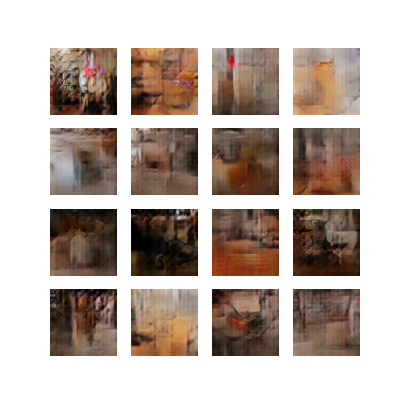
